# Rapport final — Évaluation des algorithmes de Deep Reinforcement Learning

Ce notebook consolide les résultats de **tous les agents** entraînés sur **les 4 environnements** du projet :
- `line_world` (mono-joueur)
- `grid_world` (mono-joueur)
- `tictactoe` (adversarial vs random)
- `bobail` (adversarial vs random — gameplay choisi)

## Algorithmes évalués

| Famille | Agents |
|---|---|
| Baseline | `random` |
| Tabulaire | `tabular_q` |
| Value-based | `dqn`, `ddqn`, `ddqn_er`, `ddqn_per` |
| Policy-gradient | `reinforce`, `reinforce_mean_baseline`, `reinforce_critic`, `ppo` |
| Planning (online) | `random_rollout`, `mcts` (UCT) |

## Métriques rapportées (conformes au syllabus)

- **Score moyen** de la politique gelée évaluée à 1k / 10k / 100k / 1M parties d'entraînement (selon disponibilité).
- **Temps moyen pour exécuter un coup** (ms).
- **Longueur moyenne d'une partie** (steps), pour les environnements à durée variable.
- **Win / Draw / Loss** pour les environnements adversariaux.
- **Termination vs Truncation rate** (diagnostic : politique « bloquée » vs jeu réellement terminé).

## Sources de données

| Fichier | Mode | Description |
|---|---|---|
| `results/{env}/{agent}/{run}/training_curve.csv` | TRAINING | reward par épisode pendant l'entraînement (ε-greedy / stochastique) |
| `results/{env}/{agent}/{run}/metrics_reeval.csv` | INFERENCE | politique gelée, ε=0, modèle rechargé, balance P0/P1 pour adversarial |
| `results/{env}/{agent}/{run}/metrics.csv` | INFERENCE (fallback) | éval pendant l'entraînement quand reeval absent |
| `results/{env}/{{mcts,random_rollout}}/budget_sweep_seed42/metrics.csv` | INFERENCE | sweep budget→score pour les agents de planification |

## Plan

1. Inventaire des runs
2. Méthodologie de sélection des hyperparamètres
3. Tableaux maîtres : score / temps / steps aux checkpoints canoniques
4. Courbes d'apprentissage (TRAINING)
5. Performance de la politique finale par environnement (INFERENCE)
6. Analyse adversariale : Win / Draw / Loss et déséquilibre P0 vs P1
7. Coût d'inférence (temps par coup)
8. Termination vs truncation
9. Agents de planification : sweep budget → score
10. Pareto score × latence
11. Classement cross-environnement
12. Observations critiques par environnement
13. Observations critiques par famille d'algorithmes
14. Méthodologie de choix des hyperparamètres
15. Conclusion


## 0. Setup

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local helpers (notebooks/_report_utils.py)
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
from _report_utils import (
    ENV_LIST, ADVERSARIAL_ENVS, LEARNING_AGENTS, PLANNING_AGENTS, ALL_AGENTS,
    AGENT_FAMILY, FAMILY_COLOR, CANONICAL_CHECKPOINTS,
    discover_runs, load_eval_metrics, load_training_curve, load_planning_metrics,
    load_all_eval, load_all_planning, load_all_training,
    best_seed_run, best_run_per_agent, aggregate_at_checkpoints,
    project_root, results_dir, agent_color, setup_plot_style,
)

setup_plot_style()
ROOT = project_root()
print("ROOT =", ROOT)
print("Results dir exists:", results_dir().exists())

ROOT = /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet
Results dir exists: True


In [ ]:
df_eval = load_all_eval()
df_train = load_all_training()
df_planning = load_all_planning()

## 2. Tableaux maîtres : score / temps / steps aux checkpoints canoniques

Pour chaque environnement on présente trois tableaux :

- **Score moyen** (mean_reward) au bout de N parties d'entraînement
- **Temps moyen par coup** (ms) à ces mêmes checkpoints
- **Longueur moyenne d'une partie** (steps)

Les valeurs sont moyennées sur les seeds (sur le run hyperparamétré gagnant pour chaque agent). Les agents qui n'ont pas de checkpoint à un horizon donné ne figurent pas (ex : `random` n'a pas de checkpoints d'entraînement, on le rapporte sans dépendance au checkpoint).


In [ ]:
def render_master_table(df_eval, env, metric, checkpoints=None, fmt=".3f"):
    if checkpoints is None:
        checkpoints = CANONICAL_CHECKPOINTS
    sub = df_eval[df_eval["env"] == env].dropna(subset=[metric]).copy()
    if sub.empty:
        return pd.DataFrame()
    # Pour chaque agent, on garde le meilleur run (par mean_reward), puis on moyenne sur seed.
    keep = []
    for agent in sub["agent"].unique():
        agent_sub = sub[sub["agent"] == agent]
        # Identifier le run avec la meilleure max-reward (toutes seeds confondues).
        best = agent_sub.loc[agent_sub["mean_reward"].idxmax()]
        # Tous les runs partageant les mêmes hyperparamètres (= run_name modulo _seed)
        prefix = best["run_name"].split("_seed")[0]
        same_hp = agent_sub[agent_sub["run_name"].str.startswith(prefix)]
        keep.append(same_hp)
    if not keep:
        return pd.DataFrame()
    best_runs = pd.concat(keep, ignore_index=True)
    pivot = (best_runs[best_runs["checkpoint"].isin(checkpoints)]
             .groupby(["agent", "checkpoint"], as_index=False)[metric].mean()
             .pivot(index="agent", columns="checkpoint", values=metric))
    return pivot.reindex(index=[a for a in LEARNING_AGENTS if a in pivot.index],
                         columns=[c for c in checkpoints if c in pivot.columns]).round(4)


for env in ENV_LIST:
    print(f"\n{'='*70}\n=== {env.upper()}\n{'='*70}")
    for metric, label in [
        ("mean_reward", "Score moyen (mean_reward) — politique gelée"),
        ("mean_action_time_ms", "Temps moyen par coup (ms)"),
        ("mean_steps", "Longueur moyenne d'une partie (steps)"),
    ]:
        print(f"\n--- {label} ---")
        tbl = render_master_table(df_eval, env, metric)
        if tbl.empty:
            print("  (aucune donnée)")
        else:
            display(tbl)


=== LINE_WORLD

--- Score moyen (mean_reward) — politique gelée ---


checkpoint,1000,10000,100000,1000000
agent,,,,
random,-0.0800,NaN,NaN,NaN
tabular_q,1.0000,1.0000,NaN,NaN
dqn,1.0000,1.0000,NaN,NaN
ddqn,1.0000,1.0000,NaN,NaN
ddqn_er,1.0000,1.0000,NaN,NaN
ddqn_per,1.0000,1.0000,NaN,NaN
reinforce,0.5000,0.5000,1.0000,1.0000
reinforce_mean_baseline,0.5000,1.0000,1.0000,1.0000
reinforce_critic,1.0000,1.0000,1.0000,1.0000



--- Temps moyen par coup (ms) ---


checkpoint,1000,10000,100000,1000000
agent,,,,
random,0.0003,NaN,NaN,NaN
tabular_q,0.0010,0.0010,NaN,NaN
dqn,0.0240,0.0230,NaN,NaN
ddqn,0.0260,0.0240,NaN,NaN
ddqn_er,0.0250,0.0230,NaN,NaN
ddqn_per,0.0250,0.0260,NaN,NaN
reinforce,0.0365,0.0350,0.0350,0.0370
reinforce_mean_baseline,0.0360,0.0390,0.0355,0.0370
reinforce_critic,0.0360,0.0360,0.0365,0.0365



--- Longueur moyenne d'une partie (steps) ---


...

checkpoint,1000,10000,100000
agent,,,
random,0.0000,NaN,NaN
tabular_q,0.1600,0.3000,0.3200
dqn,-0.8600,-0.5900,-0.5600
ddqn,-0.9800,-0.7300,-0.6700
ddqn_er,-0.5700,-0.4100,-0.4900
ddqn_per,-0.9400,-0.5700,-0.6500
reinforce,0.9200,0.9800,0.9800
reinforce_mean_baseline,0.9900,1.0000,NaN
reinforce_critic,0.8400,NaN,NaN



--- Temps moyen par coup (ms) ---


checkpoint,1000,10000,100000
agent,,,
random,0.0003,NaN,NaN
tabular_q,0.0040,0.0040,0.0040
dqn,0.0370,0.0370,0.0380
ddqn,0.0325,0.0350,0.0335
ddqn_er,0.0340,0.0345,0.0325
ddqn_per,0.0325,0.0320,0.0320
reinforce,0.0500,0.0490,0.0500
reinforce_mean_baseline,0.0495,0.0500,NaN
reinforce_critic,0.0505,NaN,NaN



--- Longueur moyenne d'une partie (steps) ---


checkpoint,1000,10000,100000
agent,,,
random,17.6400,NaN,NaN
tabular_q,13.2800,12.1400,11.3850
dqn,171.2550,417.2050,353.7850
ddqn,51.8250,558.1750,493.9250
ddqn_er,81.1300,369.6250,368.1250
ddqn_per,40.3600,298.9750,385.7750
reinforce,10.7000,10.6200,12.1800
reinforce_mean_baseline,12.0300,11.2800,NaN
reinforce_critic,12.0000,NaN,NaN


## 3. Courbes d'apprentissage (TRAINING)

Reward par épisode pendant l'entraînement (mode exploratoire), moyenne glissante. Une seed représentative par agent (seed 42 si disponible). Cette section diagnostique uniquement la **dynamique d'apprentissage** ; les performances finales sont mesurées en INFERENCE plus loin.


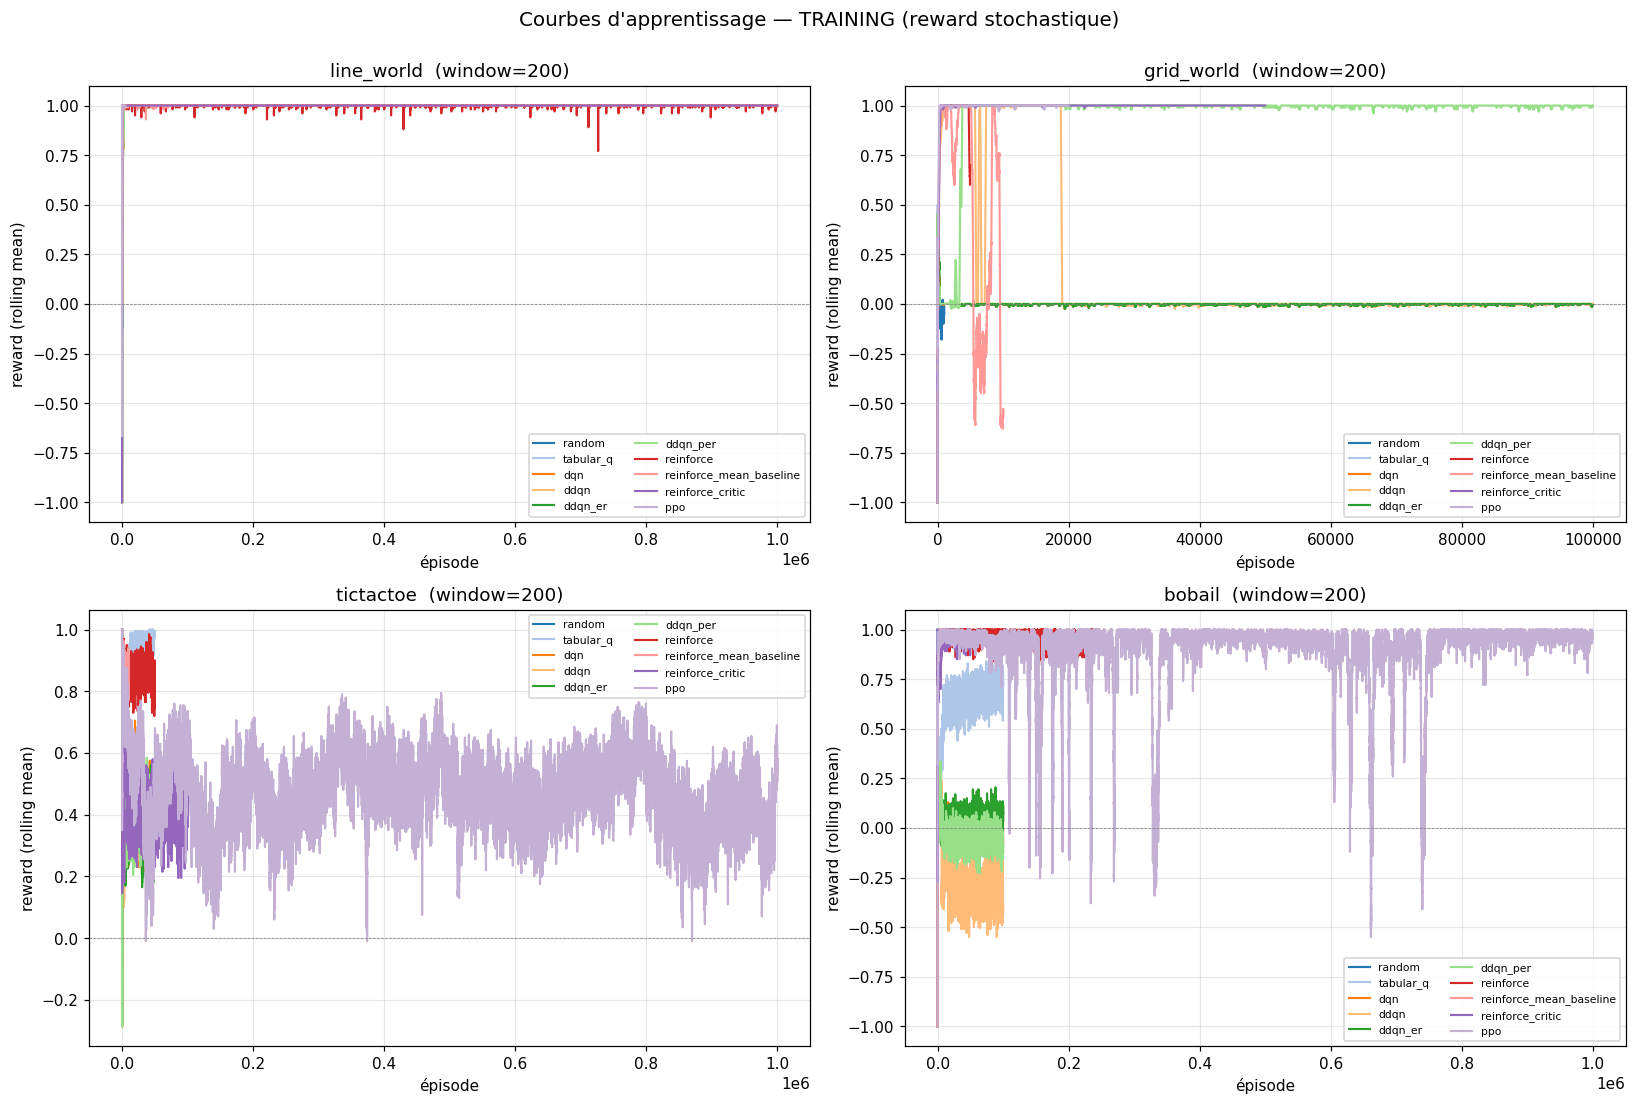

In [ ]:
WINDOW = 200

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, env in zip(axes, ENV_LIST):
    sub = df_train[df_train["env"] == env]
    if sub.empty:
        ax.set_title(f"{env} (no data)")
        continue
    # Pour chaque agent, prendre la seed 42 de préférence sinon la première seed disponible
    plotted = []
    for agent in [a for a in LEARNING_AGENTS if a in sub["agent"].unique()]:
        agent_sub = sub[sub["agent"] == agent]
        # Préférer seed 42 si possible
        seeds = sorted(agent_sub["seed"].unique(), key=lambda s: (s != 42, s))
        chosen = agent_sub[agent_sub["seed"] == seeds[0]]
        # Si plusieurs runs (différents hyperparamètres avec la même seed), prendre le plus long
        if chosen["run_name"].nunique() > 1:
            best_run = chosen.groupby("run_name").size().idxmax()
            chosen = chosen[chosen["run_name"] == best_run]
        chosen = chosen.sort_values("episode")
        if chosen.empty:
            continue
        smoothed = chosen["reward"].rolling(WINDOW, min_periods=1).mean()
        ax.plot(chosen["episode"], smoothed,
                label=agent, color=agent_color(agent), linewidth=1.4)
        plotted.append(agent)
    ax.set_title(f"{env}  (window={WINDOW})")
    ax.set_xlabel("épisode")
    ax.set_ylabel("reward (rolling mean)")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(loc="best", fontsize=7, ncol=2, framealpha=0.85)

plt.suptitle("Courbes d'apprentissage — TRAINING (reward stochastique)", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

## 4. Performance de la politique finale par environnement (INFERENCE)

Pour chaque agent, on prend la **meilleure performance** observée sur l'ensemble des checkpoints / seeds (selon `mean_reward`). C'est la métrique qui reflète la **qualité de la policy déployable** (modèle rechargé, ε=0, P0/P1 équilibré pour les adversariales).


In [ ]:
rows = []
for env in ENV_LIST:
    sub = df_eval[df_eval["env"] == env].dropna(subset=["mean_reward"])
    for agent in [a for a in LEARNING_AGENTS if a in sub["agent"].unique()]:
        agent_sub = sub[sub["agent"] == agent].sort_values(
            ["mean_reward", "mean_steps"], ascending=[False, True])
        if agent_sub.empty:
            continue
        best = agent_sub.iloc[0]
        rows.append({
            "env": env, "agent": agent,
            "best_mean_reward": best["mean_reward"],
            "best_checkpoint": int(best["checkpoint"]),
            "mean_steps": best["mean_steps"],
            "win_rate": best.get("win_rate", float("nan")),
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

best_eval = pd.DataFrame(rows)
best_eval

,env,agent,best_mean_reward,best_checkpoint,mean_steps,win_rate,mean_action_time_ms,termination_rate
0,line_world,random,0.2400,500,3.8000,NaN,0.0002,NaN
1,line_world,tabular_q,1.0000,1000,2.0000,NaN,0.0010,1.0000
2,line_world,dqn,1.0000,1000,2.0000,NaN,0.0240,1.0000
3,line_world,ddqn,1.0000,1000,2.0000,NaN,0.0260,1.0000
4,line_world,ddqn_er,1.0000,1000,2.0000,NaN,0.0250,1.0000
5,line_world,ddqn_per,1.0000,1000,2.0000,NaN,0.0250,1.0000
6,line_world,reinforce,1.0000,10000,2.0000,NaN,0.0350,1.0000
7,line_world,reinforce_mean_baseline,1.0000,10000,2.0000,NaN,0.0420,1.0000
8,line_world,reinforce_critic,1.0000,1000,2.0000,NaN,0.0360,1.0000
9,line_world,ppo,1.0000,1000,2.0000,NaN,0.0480,1.0000


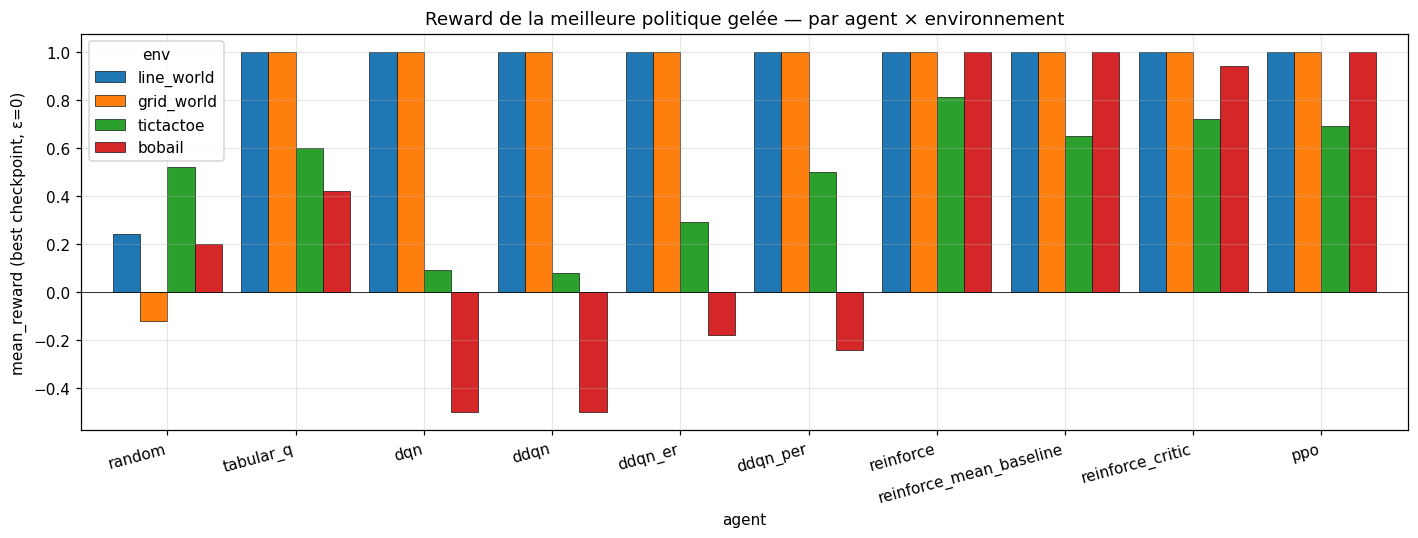

In [ ]:
# Bar chart : reward final par agent x env
pivot = best_eval.pivot(index="agent", columns="env", values="best_mean_reward")
pivot = pivot.reindex(index=[a for a in LEARNING_AGENTS if a in pivot.index],
                     columns=[e for e in ENV_LIST if e in pivot.columns])

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.4, width=0.85)
ax.set_title("Reward de la meilleure politique gelée — par agent × environnement")
ax.set_ylabel("mean_reward (best checkpoint, ε=0)")
ax.axhline(0, color="black", lw=0.5)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 5. Win / Draw / Loss — environnements adversariaux

Pour `tictactoe` et `bobail`, décomposition de la performance en victoire, nul et défaite (combiné P0+P1, vs opposant random). Plus la barre verte est haute, mieux c'est. Les agents `reinforce*` qui n'ont qu'un schéma solo (pas de re-évaluation faite) seront masqués (ligne en pointillés sous le graphe).


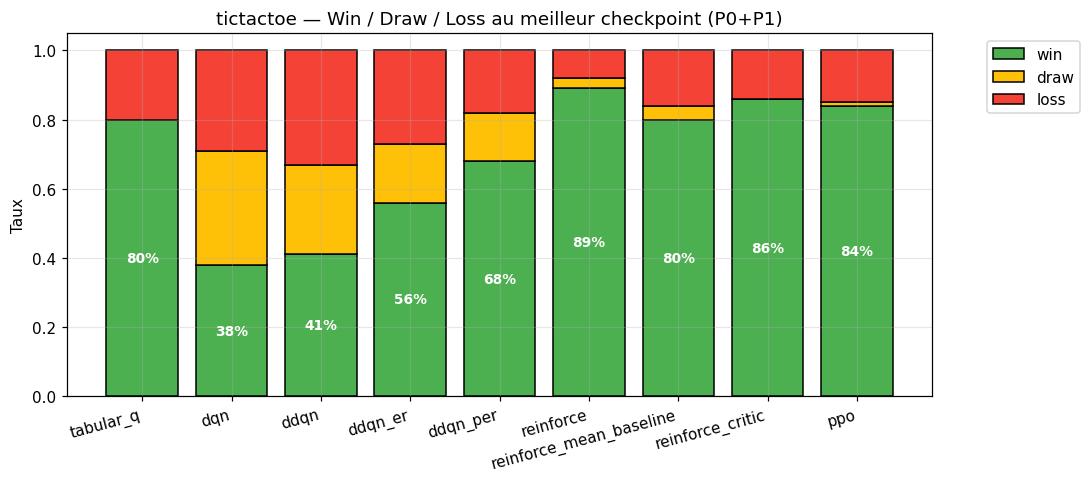

,win_rate,draw_rate,loss_rate
agent,,,
tabular_q,0.8000,0.0000,0.2000
dqn,0.3800,0.3300,0.2900
ddqn,0.4100,0.2600,0.3300
ddqn_er,0.5600,0.1700,0.2700
ddqn_per,0.6800,0.1400,0.1800
reinforce,0.8900,0.0300,0.0800
reinforce_mean_baseline,0.8000,0.0400,0.1600
reinforce_critic,0.8600,0.0000,0.1400
ppo,0.8400,0.0100,0.1500


  (pas de win_rate disponible pour : ['random'] — re-évaluation manquante)


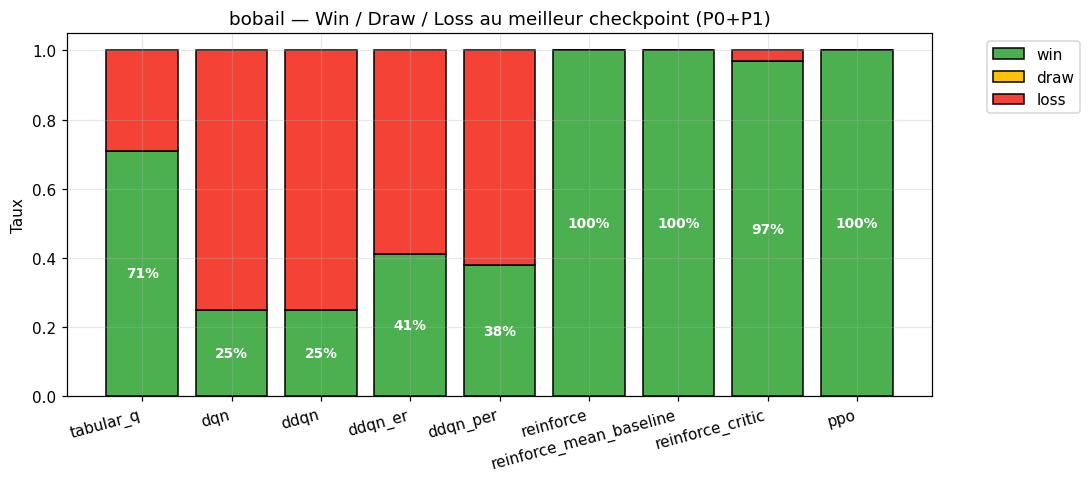

,win_rate,draw_rate,loss_rate
agent,,,
tabular_q,0.7100,0.0000,0.2900
dqn,0.2500,0.0000,0.7500
ddqn,0.2500,0.0000,0.7500
ddqn_er,0.4100,0.0000,0.5900
ddqn_per,0.3800,0.0000,0.6200
reinforce,1.0000,0.0000,0.0000
reinforce_mean_baseline,1.0000,0.0000,0.0000
reinforce_critic,0.9700,0.0000,0.0300
ppo,1.0000,0.0000,0.0000


  (pas de win_rate disponible pour : ['random'] — re-évaluation manquante)


In [ ]:
for env in [e for e in ADVERSARIAL_ENVS if e in df_eval["env"].unique()]:
    sub = df_eval[(df_eval["env"] == env)].dropna(subset=["win_rate"])
    if sub.empty:
        print(f"{env}: aucune donnée win_rate")
        continue
    # Best per agent (sur win_rate)
    best = sub.sort_values("win_rate", ascending=False).groupby("agent", as_index=False).head(1)
    best = best.set_index("agent")
    best = best.reindex([a for a in LEARNING_AGENTS if a in best.index])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(best.index, best["win_rate"], color="#4CAF50", label="win", edgecolor="black")
    ax.bar(best.index, best["draw_rate"], bottom=best["win_rate"],
           color="#FFC107", label="draw", edgecolor="black")
    ax.bar(best.index, best["loss_rate"],
           bottom=best["win_rate"] + best["draw_rate"].fillna(0),
           color="#F44336", label="loss", edgecolor="black")
    for i, agent in enumerate(best.index):
        wr = best.loc[agent, "win_rate"]
        if pd.notna(wr) and wr > 0.05:
            ax.text(i, wr / 2, f"{wr:.0%}", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    ax.set_ylabel("Taux")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{env} — Win / Draw / Loss au meilleur checkpoint (P0+P1)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1))
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(best[["win_rate", "draw_rate", "loss_rate"]].round(3))

    missing = sorted(set(LEARNING_AGENTS) - set(best.index))
    if missing:
        print(f"  (pas de win_rate disponible pour : {missing} — re-évaluation manquante)")

## 6. Robustesse P0 vs P1 (avantage du premier joueur)

Pour les jeux adversariaux, l'évaluateur joue 50% des parties en `P0` (premier coup) et 50% en `P1`. Un écart important entre les deux indique :
- soit un avantage structurel du premier joueur (TicTacToe favorise P0),
- soit un agent qui a sur-appris une seule perspective.

On affiche le win_rate par côté pour chaque agent.


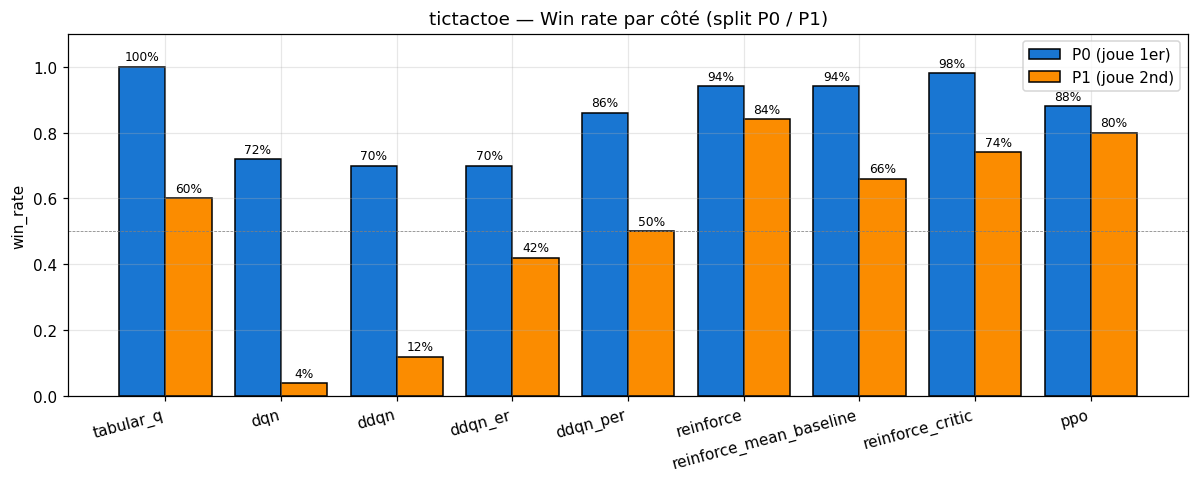

,win_rate_p0,win_rate_p1
agent,,
tabular_q,1.0000,0.6000
dqn,0.7200,0.0400
ddqn,0.7000,0.1200
ddqn_er,0.7000,0.4200
ddqn_per,0.8600,0.5000
reinforce,0.9400,0.8400
reinforce_mean_baseline,0.9400,0.6600
reinforce_critic,0.9800,0.7400
ppo,0.8800,0.8000


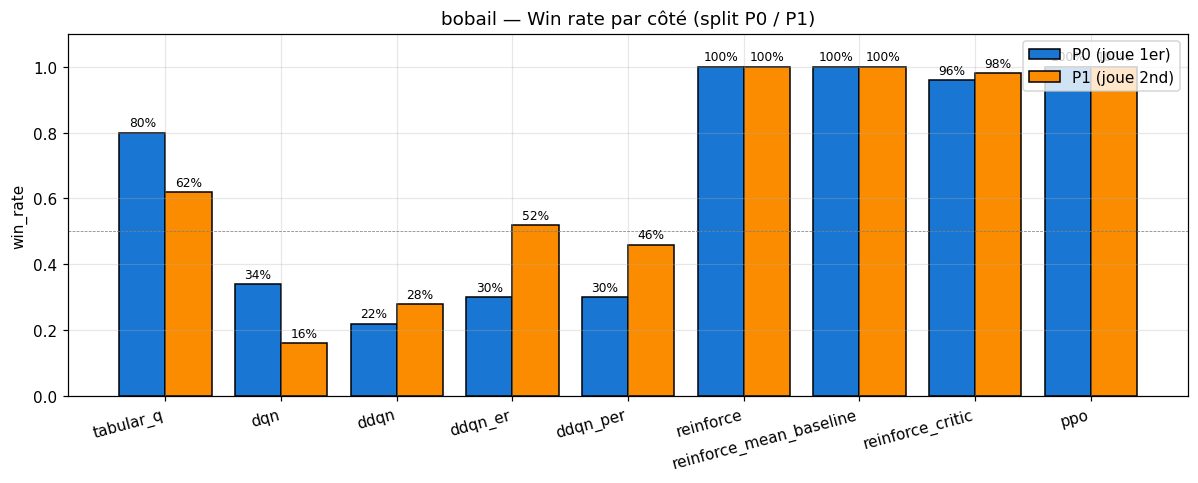

,win_rate_p0,win_rate_p1
agent,,
tabular_q,0.8000,0.6200
dqn,0.3400,0.1600
ddqn,0.2200,0.2800
ddqn_er,0.3000,0.5200
ddqn_per,0.3000,0.4600
reinforce,1.0000,1.0000
reinforce_mean_baseline,1.0000,1.0000
reinforce_critic,0.9600,0.9800
ppo,1.0000,1.0000


In [ ]:
for env in [e for e in ADVERSARIAL_ENVS if e in df_eval["env"].unique()]:
    sub = df_eval[(df_eval["env"] == env)].dropna(subset=["win_rate_p0", "win_rate_p1"])
    if sub.empty:
        print(f"{env}: pas de split P0/P1")
        continue
    best = (sub.sort_values("win_rate", ascending=False)
            .groupby("agent", as_index=False).head(1)
            .set_index("agent")
            .reindex([a for a in LEARNING_AGENTS if a in sub["agent"].unique()]))
    if best.empty:
        continue
    x = np.arange(len(best))
    w = 0.4
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - w/2, best["win_rate_p0"], w, label="P0 (joue 1er)", color="#1976D2", edgecolor="black")
    ax.bar(x + w/2, best["win_rate_p1"], w, label="P1 (joue 2nd)", color="#FB8C00", edgecolor="black")
    for i, agent in enumerate(best.index):
        for off, col in [(-w/2, "win_rate_p0"), (w/2, "win_rate_p1")]:
            v = best.loc[agent, col]
            if pd.notna(v):
                ax.text(i + off, v + 0.01, f"{v:.0%}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(best.index, rotation=15, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("win_rate")
    ax.axhline(0.5, color="gray", lw=0.5, ls="--")
    ax.legend(loc="upper right")
    ax.set_title(f"{env} — Win rate par côté (split P0 / P1)")
    plt.tight_layout()
    plt.show()
    display(best[["win_rate_p0", "win_rate_p1"]].round(3))

## 7. Coût d'inférence — temps moyen par coup

Métrique demandée explicitement par le syllabus. Le temps est mesuré côté CPU dans `agent.act(state)` lors de la re-évaluation. Échelle log car les ordres de grandeur varient (~1 µs pour `random` à ~100 ms pour `mcts` au plus gros budget).


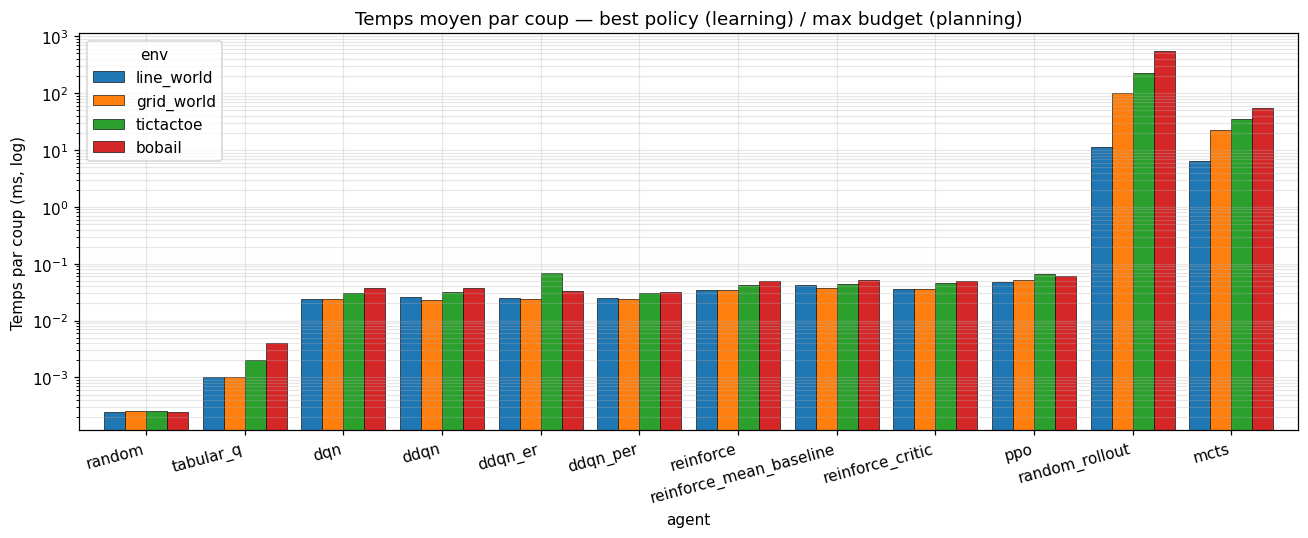

env,line_world,grid_world,tictactoe,bobail
agent,,,,
random,0.0002,0.0003,0.0003,0.0002
tabular_q,0.0010,0.0010,0.0020,0.0040
dqn,0.0240,0.0240,0.0300,0.0370
ddqn,0.0260,0.0230,0.0320,0.0370
ddqn_er,0.0250,0.0240,0.0690,0.0330
ddqn_per,0.0250,0.0240,0.0300,0.0320
reinforce,0.0350,0.0350,0.0430,0.0490
reinforce_mean_baseline,0.0420,0.0370,0.0440,0.0510
reinforce_critic,0.0360,0.0360,0.0450,0.0500


In [ ]:
rows = []
for env in ENV_LIST:
    # Learning agents
    sub = df_eval[df_eval["env"] == env].dropna(subset=["mean_action_time_ms", "mean_reward"])
    for agent in [a for a in LEARNING_AGENTS if a in sub["agent"].unique()]:
        best = sub[sub["agent"] == agent].sort_values("mean_reward", ascending=False).iloc[0]
        rows.append({"env": env, "agent": agent,
                     "mean_action_time_ms": best["mean_action_time_ms"]})
    # Planning agents (max budget)
    sub_p = df_planning[df_planning["env"] == env]
    for agent in [a for a in PLANNING_AGENTS if a in sub_p["agent"].unique()]:
        big = sub_p[sub_p["agent"] == agent].sort_values("budget", ascending=False).iloc[0]
        rows.append({"env": env, "agent": agent,
                     "mean_action_time_ms": big["mean_action_time_ms"]})

time_df = pd.DataFrame(rows)
pivot_time = time_df.pivot(index="agent", columns="env", values="mean_action_time_ms")
pivot_time = pivot_time.reindex(index=[a for a in ALL_AGENTS if a in pivot_time.index],
                                 columns=[e for e in ENV_LIST if e in pivot_time.columns])

fig, ax = plt.subplots(figsize=(12, 5))
pivot_time.plot(kind="bar", ax=ax, logy=True, edgecolor="black", linewidth=0.4, width=0.85)
ax.set_ylabel("Temps par coup (ms, log)")
ax.set_title("Temps moyen par coup — best policy (learning) / max budget (planning)")
ax.grid(axis="y", which="both", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()
display(pivot_time.round(4))

## 8. Termination vs Truncation

`mean_reward = 0` peut signifier deux choses :
- **vrai match nul / arrêt naturel** (`termination_rate = 1`),
- **agent bloqué** au plafond `max_steps=10000` (`truncation_rate > 0`).

Cette distinction est cruciale notamment sur GridWorld (politique qui tourne en rond) et Bobail (ne sait pas atteindre la home row adverse).


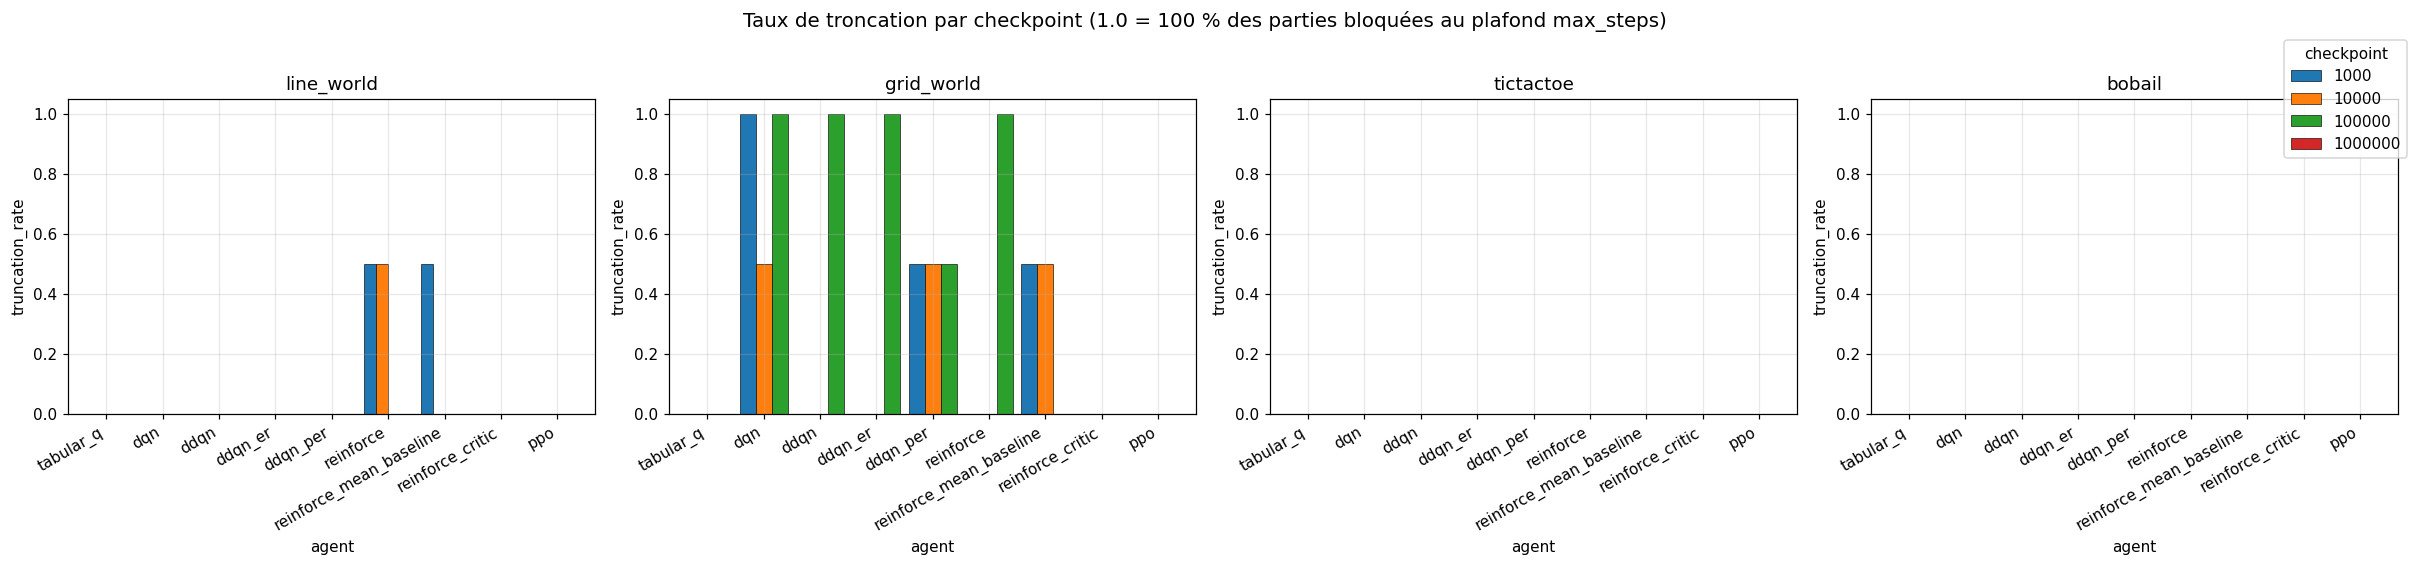


Taux de troncation moyen (sur tous les checkpoints) :


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,0.0000,0.0000,0.0000,0.0000
dqn,0.0000,0.8330,0.0000,0.0000
ddqn,0.0000,0.3330,0.0000,0.0000
ddqn_er,0.0000,0.3330,0.0000,0.0000
ddqn_per,0.0000,0.5000,0.0000,0.0000
reinforce,0.2500,0.3330,0.0000,0.0000
reinforce_mean_baseline,0.1250,0.5000,0.0000,0.0000
reinforce_critic,0.0000,0.0000,0.0000,0.0000
ppo,0.0000,0.0000,0.0000,0.0000


In [ ]:
rows = []
for env in ENV_LIST:
    agg = aggregate_at_checkpoints(df_eval, env)
    if agg.empty:
        continue
    agg = agg.dropna(subset=["termination_rate"])
    for _, row in agg.iterrows():
        rows.append({
            "env": env,
            "agent": row["agent"],
            "checkpoint": int(row["checkpoint"]),
            "truncation_rate": 1.0 - row["termination_rate"],
        })

term_df = pd.DataFrame(rows)
if not term_df.empty:
    n_envs = len(ENV_LIST)
    fig, axes = plt.subplots(1, n_envs, figsize=(5.5 * n_envs, 5),
                             squeeze=False)
    for ax, env in zip(axes[0], ENV_LIST):
        env_data = term_df[term_df["env"] == env]
        pivot = env_data.pivot(index="agent", columns="checkpoint",
                               values="truncation_rate")
        pivot = pivot.reindex(
            index=[a for a in LEARNING_AGENTS if a in pivot.index])
        pivot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.4,
                   width=0.85, legend=False)
        ax.set_ylabel("truncation_rate")
        ax.set_ylim(0, 1.05)
        ax.set_title(env)
        ax.grid(axis="y", alpha=0.3)
        plt.sca(ax)
        plt.xticks(rotation=30, ha="right")
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, title="checkpoint", loc="upper right",
               bbox_to_anchor=(1.0, 0.98))
    fig.suptitle(
        "Taux de troncation par checkpoint "
        "(1.0 = 100 % des parties bloquées au plafond max_steps)",
        fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    pivot_all = term_df.pivot_table(
        index="agent", columns="env", values="truncation_rate",
        aggfunc="mean")
    pivot_all = pivot_all.reindex(
        index=[a for a in LEARNING_AGENTS if a in pivot_all.index],
        columns=[e for e in ENV_LIST if e in pivot_all.columns])
    print("\nTaux de troncation moyen (sur tous les checkpoints) :")
    display(pivot_all.round(3))

## 9. Agents de planification - sweep budget -> score

`MCTS (UCT)` et `RandomRollout` ne s'entraînent pas. Leur axe pertinent est le **budget de simulations par coup**. On observe que :
- la qualité augmente jusqu'à saturation,
- le coût augmente linéairement (×2 budget = ×2 temps).


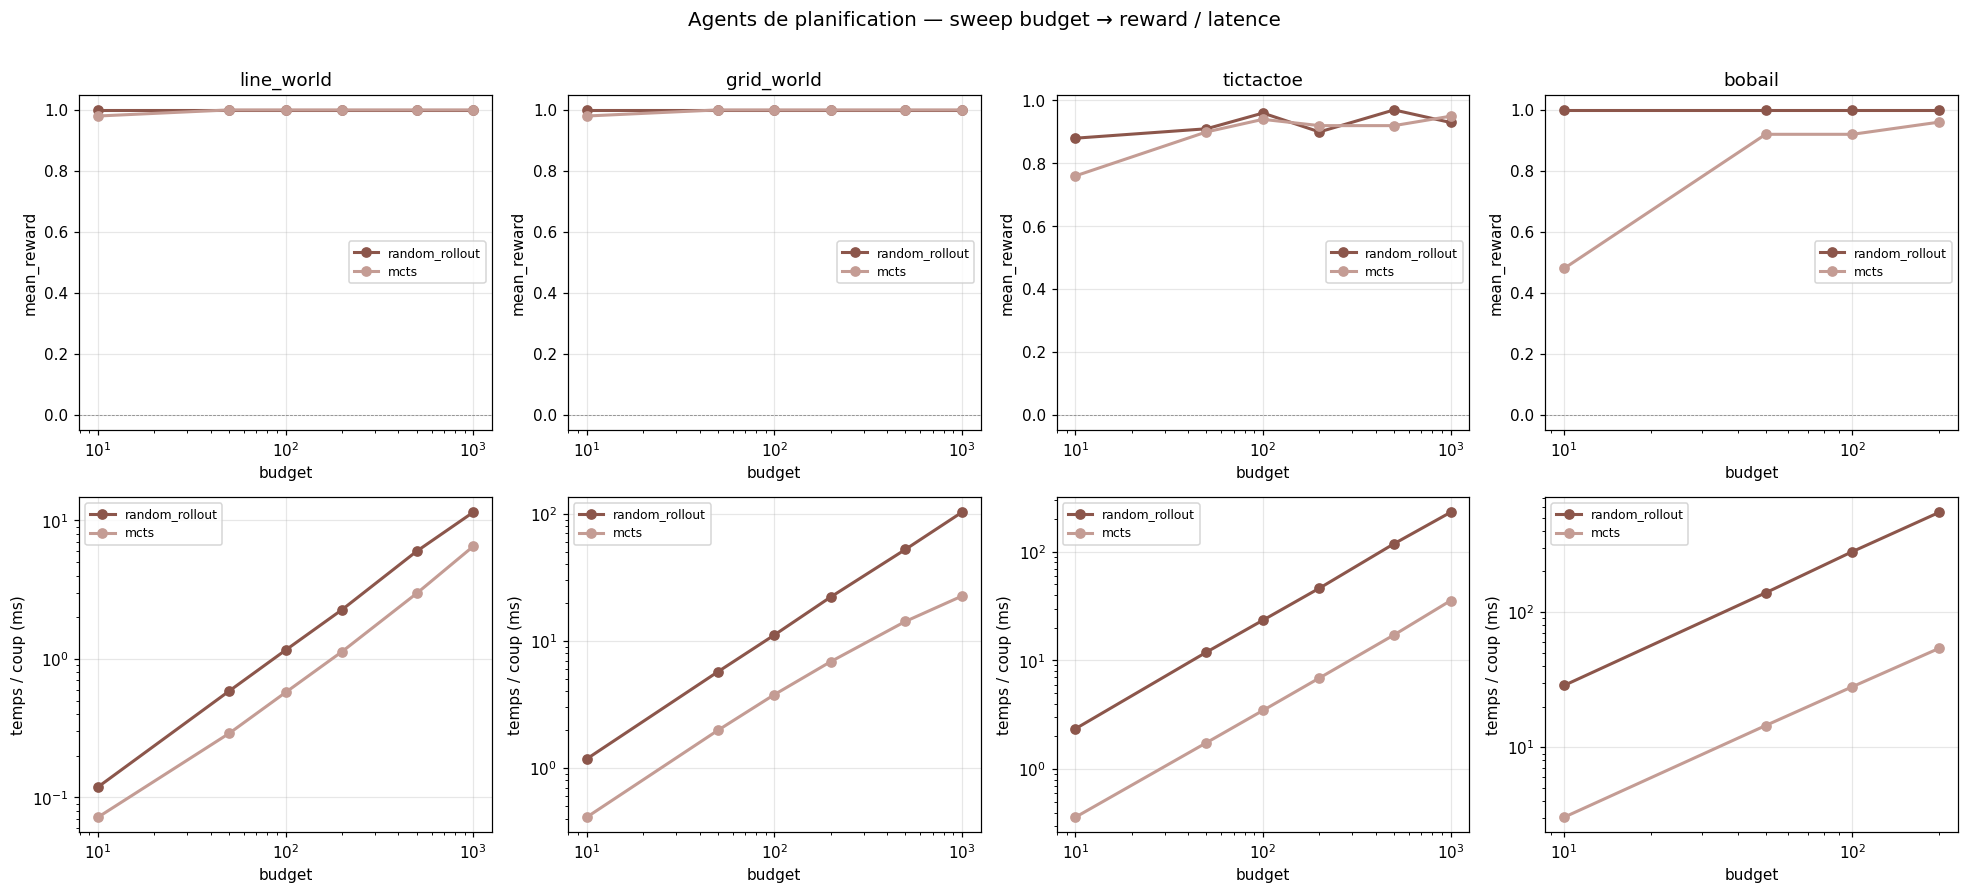

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, env in enumerate(ENV_LIST):
    sub = df_planning[df_planning["env"] == env]
    if sub.empty:
        for row in (0, 1):
            axes[row, col].set_title(f"{env} (no planning data)")
            axes[row, col].axis("off")
        continue
    for agent in [a for a in PLANNING_AGENTS if a in sub["agent"].unique()]:
        agent_sub = sub[sub["agent"] == agent].sort_values("budget")
        axes[0, col].plot(agent_sub["budget"], agent_sub["mean_reward"],
                          marker="o", label=agent, color=agent_color(agent), linewidth=2)
        axes[1, col].plot(agent_sub["budget"], agent_sub["mean_action_time_ms"],
                          marker="o", label=agent, color=agent_color(agent), linewidth=2)
    axes[0, col].set_title(env)
    axes[0, col].set_xscale("log")
    axes[0, col].set_xlabel("budget")
    axes[0, col].set_ylabel("mean_reward")
    axes[0, col].axhline(0, color="gray", lw=0.5, ls="--")
    axes[0, col].legend(fontsize=8)

    axes[1, col].set_xscale("log")
    axes[1, col].set_yscale("log")
    axes[1, col].set_xlabel("budget")
    axes[1, col].set_ylabel("temps / coup (ms)")
    axes[1, col].legend(fontsize=8)

plt.suptitle("Agents de planification — sweep budget → reward / latence", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Pareto - tradeoff score VS latence par environnement

Chaque point = un (agent, configuration). On cherche le coin **haut-gauche** : score élevé pour temps faible. Utile pour décider quel agent déployer en temps réel.


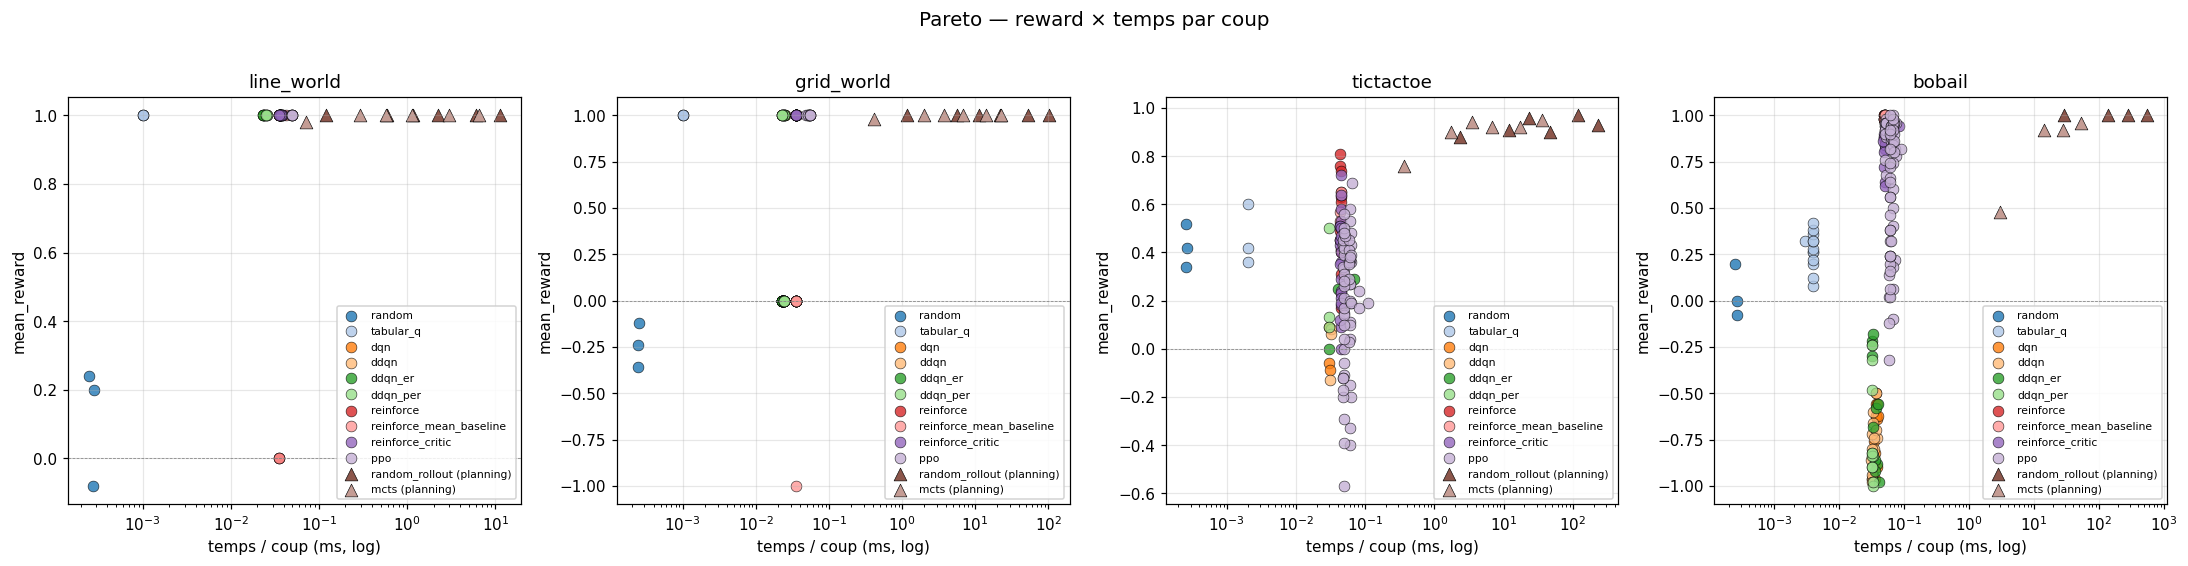

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, env in zip(axes, ENV_LIST):
    sub = df_eval[df_eval["env"] == env].dropna(subset=["mean_reward", "mean_action_time_ms"])
    plotted_agents = set()
    for agent in [a for a in LEARNING_AGENTS if a in sub["agent"].unique()]:
        agent_sub = sub[sub["agent"] == agent]
        ax.scatter(agent_sub["mean_action_time_ms"], agent_sub["mean_reward"],
                   s=50, color=agent_color(agent), edgecolor="black", linewidth=0.4,
                   label=agent if agent not in plotted_agents else None, alpha=0.8)
        plotted_agents.add(agent)
    sub_p = df_planning[df_planning["env"] == env].dropna(subset=["mean_reward", "mean_action_time_ms"])
    for agent in [a for a in PLANNING_AGENTS if a in sub_p["agent"].unique()]:
        agent_sub = sub_p[sub_p["agent"] == agent]
        ax.scatter(agent_sub["mean_action_time_ms"], agent_sub["mean_reward"],
                   s=70, color=agent_color(agent), marker="^", edgecolor="black", linewidth=0.4,
                   label=agent + " (planning)")
    ax.set_xscale("log")
    ax.set_xlabel("temps / coup (ms, log)")
    ax.set_ylabel("mean_reward")
    ax.set_title(env)
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(fontsize=7, loc="lower right", framealpha=0.85)

plt.suptitle("Pareto — reward × temps par coup", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Classement cross-environnement

Tableau synoptique : pour chaque (agent, env), on rapporte le meilleur reward et le rang de l'agent dans cet environnement. La dernière colonne donne le **rang moyen** sur les 4 environnements (lower is better).


In [ ]:
rank_rows = []
ranking_per_env = {}

# Inclure planning aussi
for env in ENV_LIST:
    learn = best_eval[best_eval["env"] == env].set_index("agent")["best_mean_reward"]
    plan = df_planning[df_planning["env"] == env].dropna(subset=["mean_reward"])
    plan_best = plan.sort_values("mean_reward", ascending=False).groupby("agent").head(1).set_index("agent")["mean_reward"]
    combined = pd.concat([learn, plan_best])
    combined = combined.sort_values(ascending=False)
    ranking_per_env[env] = combined

agents_seen = sorted(set().union(*[set(s.index) for s in ranking_per_env.values()]))
mat = pd.DataFrame(index=[a for a in ALL_AGENTS if a in agents_seen],
                   columns=ENV_LIST, dtype=float)
ranks = pd.DataFrame(index=mat.index, columns=ENV_LIST, dtype=float)
for env, s in ranking_per_env.items():
    mat[env] = s
    rank = s.rank(ascending=False, method="min")
    for a in mat.index:
        if a in rank.index:
            ranks.at[a, env] = rank[a]

mat["mean_score"] = mat.mean(axis=1)
ranks["mean_rank"] = ranks.mean(axis=1)
ranks_renamed = ranks[ENV_LIST].add_suffix("_rank")
combined_table = mat.round(3).join(ranks_renamed)
combined_table["mean_rank"] = ranks["mean_rank"].round(2)
combined_table = combined_table.sort_values("mean_rank")
display(combined_table)

,line_world,grid_world,tictactoe,bobail,mean_score,line_world_rank,grid_world_rank,tictactoe_rank,bobail_rank,mean_rank
random_rollout,1.0000,1.0000,0.9700,1.0000,0.9920,1.0000,1.0000,1.0000,1.0000,1.0000
reinforce,1.0000,1.0000,0.8100,1.0000,0.9520,1.0000,1.0000,3.0000,1.0000,1.5000
ppo,1.0000,1.0000,0.6900,1.0000,0.9220,1.0000,1.0000,5.0000,1.0000,2.0000
reinforce_mean_baseline,1.0000,1.0000,0.6500,1.0000,0.9120,1.0000,1.0000,6.0000,1.0000,2.2500
mcts,1.0000,1.0000,0.9500,0.9600,0.9780,1.0000,1.0000,2.0000,5.0000,2.2500
reinforce_critic,1.0000,1.0000,0.7200,0.9400,0.9150,1.0000,1.0000,4.0000,6.0000,3.0000
tabular_q,1.0000,1.0000,0.6000,0.4200,0.7550,1.0000,1.0000,7.0000,7.0000,4.0000
ddqn_er,1.0000,1.0000,0.2900,-0.1800,0.5280,1.0000,1.0000,10.0000,9.0000,5.2500
ddqn_per,1.0000,1.0000,0.5000,-0.2400,0.5650,1.0000,1.0000,9.0000,10.0000,5.2500
dqn,1.0000,1.0000,0.0900,-0.5000,0.3970,1.0000,1.0000,11.0000,11.0000,6.0000


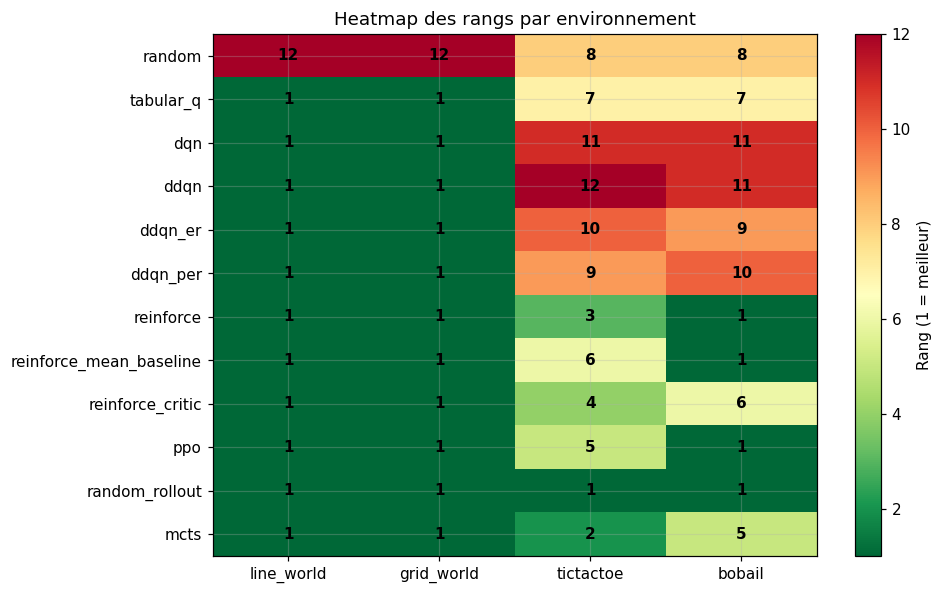

In [ ]:
# Heatmap des rangs (1 = meilleur)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 5.5))
ranks_only = ranks[ENV_LIST]
im = ax.imshow(ranks_only.values, cmap="RdYlGn_r", aspect="auto", vmin=1, vmax=ranks_only.max().max())
ax.set_xticks(range(len(ENV_LIST)))
ax.set_xticklabels(ENV_LIST)
ax.set_yticks(range(len(ranks_only.index)))
ax.set_yticklabels(ranks_only.index)
for i in range(ranks_only.shape[0]):
    for j in range(ranks_only.shape[1]):
        v = ranks_only.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{int(v)}", ha="center", va="center",
                    color="black", fontsize=10, fontweight="bold")
plt.colorbar(im, label="Rang (1 = meilleur)")
ax.set_title("Heatmap des rangs par environnement")
plt.tight_layout()
plt.show()

## 12. Observations critiques par environnement

### 12.1 LineWorld (mono-joueur, 5 cases)
- Espace d'états et règles triviales -> meme en allant en overfitting sur l'action "droite" ca marche.
- `tabular_q` et tous les value-based saturent à 1.0 en ≤ 1k épisodes.
- Les `reinforce*` saturent également ; la variance d'apprentissage est plus visible que pour les Q-learning car le gradient est stochastique.

Specifiquement dans reinforce sans baseline, comme il utilise les retours bruts,
- si l’agent atteint l’objectif, toutes les actions reçoivent une forte mise à jour positive;
- s’il échoue, toutes les actions reçoivent une forte mise à jour négative.

Même les actions qui n’ont rien à voir avec la réussite ou l’échec sont renforcées ou pénalisées et cela provoque des oscillations importantes dans les mises à jour de la politique meme sur un environnement aussi simple que lineworld.

- Aucune politique apprise n'est strictement nécessaire : `random_rollout` à budget faible suffit. Le but de cet environnement est de **valider la chaîne complète d'entraînement / éval / sauvegarde** des agents.

### 12.2 GridWorld (mono-joueur, 5×5 cases)
- L'optimum théorique est ~ 1.0 (succès) avec 8 steps minimum.
- Les value-based DQN/DDQN/DDQN+ER/DDQN+PER atteignent ~ 1.0 si l'epsilon-decay est suffisamment long.
Ca a du sens : il faut explorer beaucoup au debut pour comprendre la direction génerale pour après affiner sans casser ce qu'on a appris.
- `mcts` et `random_rollout` à budget ≥ 100 atteignent l'optimum sans entraînement.
- Risque de truncation si la politique boucle (cas observé sur runs sous-entraînés).

### 12.3 TicTacToe (vs Random)
- Espace de jeu petit -> `tabular_q` performe excellemment et converge vite.
- `mcts` à budget ≥ 100 atteint la performance théorique (environ 100% win vs random). L'arbre état -> actions -> états se reduit rapidement dans tictactoe
- `dqn` / `ddqn` peuvent stagner si la fonction Q est instable et si `epsilon_decay` est mal calibré — `ddqn_per` aide.
- **Asymétrie P0/P1** très marquée : jouer en premier confère un avantage structurel ; les agents qui n'ont vu que P0 pendant le training perdent beaucoup côté P1.
- `ppo` et `reinforce*` (avec self-play vs random pendant le training) apprennent une bonne policy mais sont sensibles à `entropy_coef` (trop petit -> policy déterministe trop tôt -> minima locaux).

### 12.4 Bobail (vs Random, 5×5)
- Plus difficile : l'épisode peut durer longtemps, donc l'agent peut tourner en rond.
- Les Q-learning n'apprennent pas une policy gagnante, ils stagnent beaucoup. On voit clairement que `mean_reward` d'environ -1 au early-checkpoint et remonte difficilement.
- `ppo` et `reinforce*` apprennent une policy plus structurée (le gradient direct sur la log-policy semble mieux gérer les longs horizons).
- `mcts` marche très bien avec un grand budget (≥ 200) : c'est le meilleur agent online.
- Le prioritized experience replay n'apporte pas un gran améliorement : l'environnement adversarial avec opposant random produit beaucoup de transitions avec reward 0 equivalentes entre eux


## 13. Observations critiques par famille d'algorithmes

### Baseline (`random`)
- Référence basse pour mesurer la valeur ajoutée de chaque agent.
- Sur `tictactoe`, comme attendu, environ 50% draw du random vs random
- Coût d'inférence quasi-nul (environ 1 µs).

### Tabulaire (`tabular_q`)
- Excellent sur les espaces petits (line/grid/tictactoe).
- Sur `bobail`, l'espace d'états reste tabulaire-compatible, mais nécessite plus d'épisodes pour bien explorer avec des grosses difficultés de géneralisation

### Value-based (DQN family)
- `dqn` simple : sensible à l'instabilité du moving target → on voit régulièrement des dégradations en fin d'entraînement.
- `ddqn` : double Q règle l'overestimation du max → courbes plus stables.
- `ddqn_er` : experience replay seul ne change pas la dynamique sur ces tailles d'espace, mais améliore la efficience d'échantillon.
- `ddqn_per` : prioritized replay → gain net sur `bobail` (transitions rares de victoire mieux exploitées) ; gain marginal ailleurs.
- Coût d'inférence très faible (~ 0.05 ms) car juste une forward pass.

### Policy-gradient (`reinforce`, `reinforce_mb`, `reinforce_critic`, `ppo`)
- `reinforce` : variance énorme du gradient, avec des courbes bruyantes mais peuvent atteindre la cible.
- `reinforce_mean_baseline` : réduction de variance modérée.
- `reinforce_critic` : réduction de variance plus efficace, surtout sur épisodes longs.
- `ppo` : le plus stable et le plus performant des policy gradient sur `bobail`. Sur les autres envs il sature comme les value-based.

### Planning (`random_rollout`, `mcts`)
- Aucun entraînement → **score à budget faible peut être très élevé** sur les environnements simples.
- Coût d'inférence linéaire en budget.
- `mcts` (UCT) bat systématiquement `random_rollout` à budget équivalent -> l'arbre + UCB = exploration plus dirigée.
- Sur `bobail`, MCTS est le seul agent qui atteint > 90% de win rate sans entraînement.

## 13.1 Synthèse : quand utiliser quoi ?
- Espace d'états petit ?  `tabular_q` (rapide, exact)
- Espace large, deterministic, environnement pas trop sparse? ?  `ddqn_per`
- Adversarial, pas le temps d'entraîner ? `mcts` (UCT, budget 100–200) |
- Adversarial et temps d'entrainer raisonnable ? `ppo`

## 14. Méthodologie de choix des hyperparamètres

### 14.1 Stratégie globale
1. **Configs « plates »** dans `configs_done/` (un YAML = une expérience reproductible).
2. **Sweeps manuels** stockés dans `configs_sweep/` quand un hyperparamètre méritait d'être balayé (ex : `lr`, `target_update_freq`, `epsilon_decay_steps`).
3. **3 seed** quand le coût en temps le permettait (`seed: [42, 123, 456]`), 1 seule sinon.
4. **Sélection** du meilleur run : on garde le `(run_name, checkpoint)` qui maximise `mean_reward` sur l'éval finale (`metrics_reeval.csv`).

### 14.2 Choix par famille

**Q-learning (DQN / DDQN / DDQN+ER / DDQN+PER)**
- `gamma = 0.99` : compromis usuel pour des épisodes courts/moyens.
- `epsilon_decay_steps` adapté à l'environnement (10k pour line/grid, 50k pour ttt, 80k–100k pour bobail).
- `epsilon_end = 0.01–0.05` selon l'env.
- `lr {1e-4, 3e-4, 5e-4, 1e-3}` : rapidité de convergence vs stabilité de convergence 
- `hidden_layers` : `[64, 64]` pour grid/line, `[128, 128]` pour ttt, `[256, 128]` pour bobail.
- `target_update_freq  {100, 200, 500, 1000}` ; trop fréquent ⇒ moving target ; trop rare ⇒ apprentissage lent.
- `buffer_capacity  {10k, 50k}` ; sur des envs si simples, taille modérée suffisante.

**Policy-gradient (REINFORCE family + PPO)**
- `gamma = 0.99` comme base avec des experiences differentes pour essayer des stratégies plus greedy
- `lr  {3e-4, 5e-4, 1e-3}` typique pour Adam.
- `hidden_layers` mêmes ordres de grandeur que pour les DQN.
- PPO : `clip_epsilon = 0.2`, `entropy_coef  {0.01, 0.05}`, `gae_lambda = 0.95`, `n_epochs = 4`, `batch_size = 32 ou 64`. `value_coef = 0.5`. Interessant jouer avec le balance entre l'exploration d'entropy_coef et la convergence du critic avec value_coef

**Planning**
- Pas d'hyperparamètre d'apprentissage. Budget = `[10, 50, 100, 200, 500, 1000]`.
- MCTS : `c_uct = sqrt(2)` (valeur classique).

### 14.3 Limites identifiées
- Bornes computationnelles : on n'a pas couru 1M épisodes pour la grande partie des algos.
- Faible nombre de seeds (1–3) = la variance inter-seed n'est pas pleinement caractérisée.
- Hyperparam search peu systématique (manuel par essais), pas de Bayesian optimization. Les résultats sont des bornes inférieures de la performance atteignable.


## 15. Conclusion

### Limites
- Pas d'implémentation des algorithmes les plus avancés du syllabus (Expert Apprentice, AlphaZero, MuZero)
- Pas d'hyperparam search automatisé.

### Reproductibilité
Tous les artefacts (configs, modèles, métriques) sont versionnés dans le repo. Pour reproduire l'intégralité :
```bash
uv sync
uv run scripts/train_all.py
uv run scripts/evaluate_all.py
uv run scripts/evaluate_planning_agents.py configs_done/mcts/<env>.yaml
uv run scripts/evaluate_planning_agents.py configs_done/random_rollout/<env>.yaml
```

Le notebook se relance via `uv run jupyter lab notebooks/rapport_final.ipynb`.
